In [1]:
# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 2. Load Dataset

df = pd.read_csv("StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
# 3. Dataset Information

print("Shape:", df.shape)

df.info()

Shape: (1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [4]:
# 4. Check Missing Values

df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [5]:
# 5. Statistical Summary

df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
# 6. Check Columns

df.columns

Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')

In [7]:
# 7. Create Total Score

df["total_score"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
)

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218
1,female,group C,some college,standard,completed,69,90,88,247
2,female,group B,master's degree,standard,none,90,95,93,278
3,male,group A,associate's degree,free/reduced,none,47,57,44,148
4,male,group C,some college,standard,none,76,78,75,229


In [8]:
# 8. Average Score

df["average_score"] = df["total_score"] / 3

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [9]:
# 9. Gender-wise Average Score

gender_avg = df.groupby("gender")["average_score"].mean()

print(gender_avg)

gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64


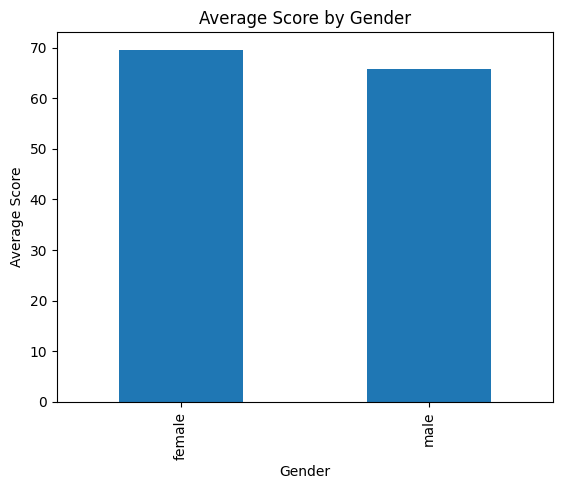

In [10]:
# 10. Visualization - Gender vs Average Score

gender_avg.plot(kind="bar")

plt.title("Average Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Score")
plt.show()

In [11]:
# 11. Test Preparation vs Score

prep_avg = df.groupby(
    "test preparation course"
)["average_score"].mean()

print(prep_avg)

test preparation course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64


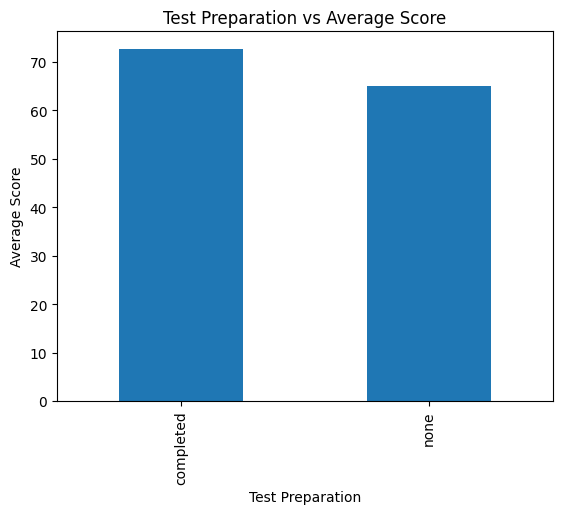

In [12]:
# 12. Visualization

prep_avg.plot(kind="bar")

plt.title("Test Preparation vs Average Score")
plt.xlabel("Test Preparation")
plt.ylabel("Average Score")
plt.show()

In [13]:
# 13. Correlation

numeric_df = df[
    ["math score", "reading score", "writing score"]
]

print(numeric_df.corr())

               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


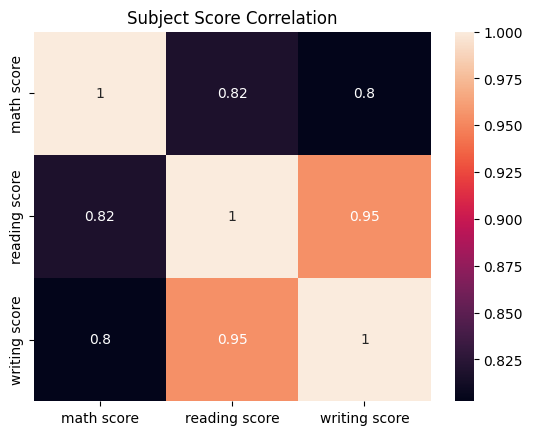

In [14]:
# 14. Correlation Heatmap

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Subject Score Correlation")
plt.show()

In [15]:
# 15. Import Machine Learning Libraries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [16]:
# 16. Independent and Dependent Variables

X = df[["math score", "reading score"]]

y = df["writing score"]

In [17]:
# 17. Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 2)
Testing Data: (200, 2)


In [18]:
# 18. Create Model

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [19]:
# 19. Prediction

y_pred = model.predict(X_test)

print(y_pred[:10])

[85.59822883 64.17343143 72.63647191 75.96410913 82.29300047 74.58185589
 69.04967819 59.55634117 73.12921131 52.78269291]


In [20]:
# 20. Model Evaluation

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 3.8380082149660915
MSE : 23.665243336391317
RMSE: 4.8646935501006965
R2 Score: 0.9018108855760416


In [21]:
# 21. Actual vs Predicted

result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
0,84,85.598229
1,73,64.173431
2,72,72.636472
3,73,75.964109
4,78,82.293000
5,78,74.581856
6,63,69.049678
7,62,59.556341
8,72,73.129211
9,41,52.782693


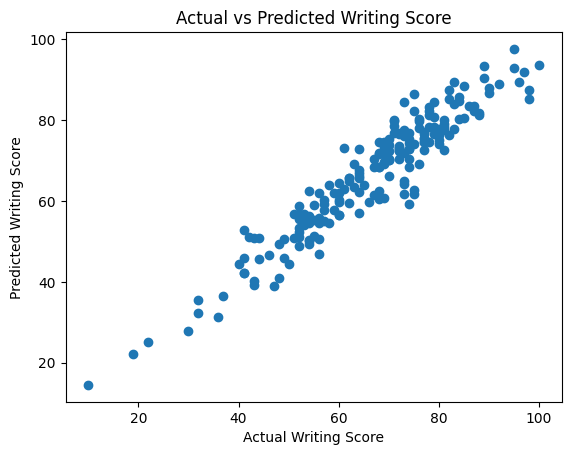

In [22]:
# 22. Actual vs Predicted Graph

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Writing Score")
plt.ylabel("Predicted Writing Score")
plt.title("Actual vs Predicted Writing Score")

plt.show()

Enter Reading Score: 89
Prediction Writing Score: 88
R2 score: 0.9112574888913137


<Axes: ylabel='writing score'>

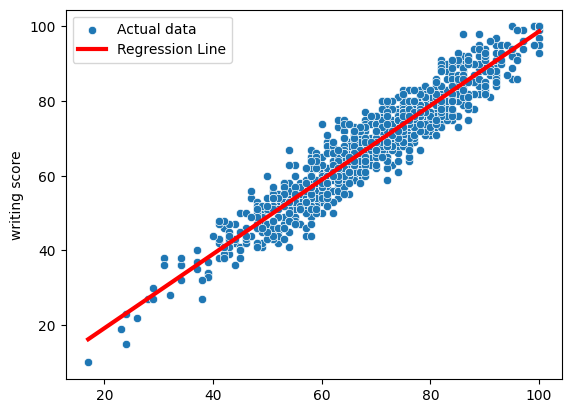

In [23]:
# linear regression

from sklearn.linear_model import LinearRegression as lr
from sklearn.metrics import r2_score
import seaborn as sb
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("StudentsPerformance.csv")

# Linear Regression
x = df[['reading score']]
y = df['writing score']

m = lr()
m.fit(x, y)

# Prediction
y_pred = m.predict(x)

# User Input
reading = int(input("Enter Reading Score: "))

new_data = pd.DataFrame({
    "reading score": [reading]
})

pred = m.predict(new_data)

print("Prediction Writing Score:", round(pred[0]))

# R2 Score
r2 = r2_score(y, y_pred)

print("R2 score:", r2)

# Regression line
x_range = np.linspace(
    x['reading score'].min(),
    x['reading score'].max(),
    100
)

x_new = pd.DataFrame({
    "reading score": x_range
})

y_new = m.predict(x_new)

# Actual data
sb.scatterplot(
    x=x.to_numpy().flatten(),
    y=y,
    label="Actual data"
)

# Regression Line
sb.lineplot(
    x=x_range,
    y=y_new,
    color="red",
    linewidth=3,
    label="Regression Line"
)